In [1]:
import sys, platform
from pathlib import Path
import torch

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"env={Path(sys.prefix).name}  python={platform.python_version()}  torch={torch.__version__}  device={device}")

env=proj-iv  python=3.12.14  torch=2.13.0  device=cpu


# Base compilada Gas Flare

O objetivo de modelagem é um modelo preditivo com o máximo de série disponível.
Cada família abaixo alinha-se à **primeira data do PPI** (`ppi_daily`; hoje **2022-01-05**).
Uma camada nova entra a partir dessa âncora. NaNs antes do início da fonte são esperados. Não corte a carga a “só anos recentes”.

O notebook junta as tabelas do snapshot em um `master_df` largo:

| Família | Tabelas | Frequência nativa | Âncora de data |
|--------|--------|-------------|-------------|
| PPI | `ppi_daily` | diária | `report_date` |
| Preço | `anp/petrobras_distributor_weekly_{gasoline,diesel}` | semanal | `week_start` |
| Vendas | `anp_fuel_sales` | mensal | `month` |
| Vendas | `pbr_quarterly_sales` | trimestral | `quarter_end` |
| Finanças | `pbr_quarterly_diesel_gasoline` | trimestral | `quarter_end` |
| Proxies | `abcr_traffic_index`, `ibge_indicators` | mensal | `month` |
| Inflação | `inflation_monthly` | mensal | `month` |
| Ação | `equity_daily` (PETR4) | diária | `tradedate` |

## Atualidade da fonte (snapshot congelado)

Este projeto lê **somente** `data/gas_flare.sqlite`. Não há Postgres e não há pipeline ao vivo. A tabela abaixo registra a defasagem nativa de publicação no arquivo congelado.

| Família | Tabela(s) | Cadência da fonte | Defasagem típica | Tarefa de origem | Prontidão (verde / amarelo) |
|--------|----------|----------------|--------------------|---------------|----------------------------|
| PPI | `ppi_daily` | posts ABICOM (~2–3×/semana) | 3–7 dias | `ppi` | semanal: ≤10 / ≤21 dias |
| Preço — ANP | `anp_distributor_weekly_{gasoline,diesel}` | levantamento semanal | ~10–17 dias (arquivo oficial ponderado ~1–2 semanas atrasado) | `price` | weekly_anp: ≤18 / ≤28 dias |
| Preço — PBR | `petrobras_distributor_weekly_{gasoline,diesel}` | PDFs irregulares às distribuidoras | pode ficar **meses** sem mudança (fato; não é atraso) | `price` | irregular: sempre verde |
| Vendas — ANP | `anp_fuel_sales` | volume nacional mensal | ~2 meses | `sales` | mensal: ≤80 / ≤110 dias |
| Vendas — PBR | `pbr_quarterly_sales` | Relatório de Produção e Vendas | ~1–2 meses após o trimestre | `sales` | trimestral: ≤135 / ≤200 dias |
| Finanças | `pbr_quarterly_diesel_gasoline` | volume e receita trimestrais | mesmo ciclo do relatório de vendas | `finance` | trimestral: ≤135 / ≤200 dias |
| Proxies — ABCR | `abcr_traffic_index` | índice mensal de pedágio | ~1 mês | `sales` | mensal: ≤80 / ≤110 dias |
| Proxies — IBGE | `ibge_indicators` | SIDRA mensal (PMC, PIM, desemprego) | ~1,5–2 meses | `sales` | mensal: ≤80 / ≤110 dias |
| Inflação — IPCA | `inflation_monthly` | IPCA mensal (BCB SGS 433) | ~dia 12 do mês seguinte | congelado | monthly_cpi: ≤75 / ≤95 dias (desde o início do mês) |
| Inflação — IPCA-15 | `inflation_monthly` | prévia do IPCA (BCB SGS 7478) | ~dia 25 do mês de referência | congelado | monthly_cpi_early: ≤55 / ≤75 dias |
| Inflação — IGP-M | `inflation_monthly` | preços gerais FGV (BCB SGS 189) | fim do mês | congelado | monthly_cpi: ≤75 / ≤95 dias |
| Ação — PETR4 | `equity_daily` | barras diárias B3 | pregão | congelado | semanal: ≤10 / ≤21 dias |

A célula abaixo classifica a idade do snapshot com as mesmas faixas da operação Gas Flare. Serve de contexto. Não é um monitor ao vivo.

**Alinhamento:** o índice mestre são dias úteis do mínimo ao máximo do PPI (**2022-01-05**). O PPI entra por junção à esquerda, sem preenchimento. Blocos de frequência menor (e a ação) são **cortados na âncora do PPI** e depois preenchidos para a frente nesse índice.

**Início nativo vs. âncora do PPI:** PETR4 em `equity_daily` começa em **2022-02-01**. Espere NaNs no índice mestre em janeiro de 2022. A inflação está gravada desde **2022-01** (carimbos de início de mês antes de 2022-01-05 saem no corte do PPI).


## Dicionário de colunas (`master_df`)

Coluna de índice: **`date`** — dia útil (segunda a sexta). Construída do mínimo ao máximo do PPI com `pd.bdate_range`. Valores de PPI só nas datas de publicação da ABICOM (NaN nas demais). As outras colunas avançam a partir da data nativa da observação.

| Coluna | Tabela fonte | Frequência | Unidade | Descrição |
|--------|--------------|-------------|------|-------------|
| **PPI — Índice de Paridade de Preços (ABICOM)** | | | | |
| `ppi_pbr_gas_R` | `ppi_daily` | diária | R\$/L | Diferencial Petrobras gasolina vs. paridade (absoluto) |
| `ppi_pbr_gas_pct` | `ppi_daily` | diária | % | Diferencial Petrobras gasolina vs. paridade (%) |
| `ppi_pbr_die_R` | `ppi_daily` | diária | R\$/L | Diferencial Petrobras diesel vs. paridade (absoluto) |
| `ppi_pbr_die_pct` | `ppi_daily` | diária | % | Diferencial Petrobras diesel vs. paridade (%) |
| `ppi_ind_gas_R` | `ppi_daily` | diária | R\$/L | Diferencial independentes gasolina vs. paridade (absoluto) |
| `ppi_ind_gas_pct` | `ppi_daily` | diária | % | Diferencial independentes gasolina vs. paridade (%) |
| `ppi_ind_die_R` | `ppi_daily` | diária | R\$/L | Diferencial independentes diesel vs. paridade (absoluto) |
| `ppi_ind_die_pct` | `ppi_daily` | diária | % | Diferencial independentes diesel vs. paridade (%) |
| **Preço — médias semanais na distribuidora** | | | | |
| `price_anp_gasoline_rs_l` | `anp_distributor_weekly_gasoline` | semanal | R\$/L | Preço médio nacional ANP da gasolina (carimbo `week_start`, preenchido à frente) |
| `price_anp_diesel_rs_l` | `anp_distributor_weekly_diesel` | semanal | R\$/L | Preço médio nacional ANP do diesel |
| `price_pbr_gasoline_rs_l` | `petrobras_distributor_weekly_gasoline` | semanal | R\$/L | Preço Petrobras da gasolina às distribuidoras |
| `price_pbr_diesel_rs_l` | `petrobras_distributor_weekly_diesel` | semanal | R\$/L | Preço Petrobras do diesel às distribuidoras |
| **Vendas — volume nacional mensal ANP** | | | | |
| `sales_anp_diesel_m3` | `anp_fuel_sales` | mensal | m³ | Volume nacional de diesel (soma dos estados; carimbo no dia 1, preenchido à frente) |
| `sales_anp_gasolina_c_m3` | `anp_fuel_sales` | mensal | m³ | Volume nacional de gasolina C |
| **Vendas — volume doméstico trimestral Petrobras** | | | | |
| `sales_pbr_diesel_mbpd` | `pbr_quarterly_sales` | trimestral | mbpd | Venda doméstica de diesel no Relatório de Produção e Vendas (carimbo `quarter_end`, preenchido à frente) |
| `sales_pbr_gasolina_c_mbpd` | `pbr_quarterly_sales` | trimestral | mbpd | Venda doméstica de gasolina C |
| **Finanças — volume e receita trimestrais Petrobras** | | | | |
| `fin_diesel_mbpd` | `pbr_quarterly_diesel_gasoline` | trimestral | mbpd | Volume de diesel (mesma origem do Exhibit I que `sales_pbr_diesel_mbpd`) |
| `fin_gasoline_mbpd` | `pbr_quarterly_diesel_gasoline` | trimestral | mbpd | Volume de gasolina |
| `fin_diesel_revenue_rsmn` | `pbr_quarterly_diesel_gasoline` | trimestral | R\$ mi | Receita de diesel nas demonstrações |
| `fin_gasoline_revenue_rsmn` | `pbr_quarterly_diesel_gasoline` | trimestral | R\$ mi | Receita de gasolina |
| `fin_total_revenue_rsmn` | `pbr_quarterly_diesel_gasoline` | trimestral | R\$ mi | Soma das receitas de diesel e gasolina |
| `fin_rtm_sales_revenue_rsmn` | `pbr_quarterly_diesel_gasoline` | trimestral | R\$ mi | Receita de vendas do segmento RT&M (nota 8 do ITR) |
| `fin_rtm_gross_profit_rsmn` | `pbr_quarterly_diesel_gasoline` | trimestral | R\$ mi | Lucro bruto do segmento RT&M |
| `fin_rtm_gross_margin_pct` | `pbr_quarterly_diesel_gasoline` | trimestral | % | Margem bruta RT&M = lucro bruto / vendas do segmento |
| **Proxies — índice de tráfego ABCR** | | | | |
| `abcr_light_index` | `abcr_traffic_index` | mensal | índice | Tráfego leve (proxy de gasolina / mobilidade) |
| `abcr_heavy_index` | `abcr_traffic_index` | mensal | índice | Tráfego pesado (proxy de diesel / frete) |
| `abcr_total_index` | `abcr_traffic_index` | mensal | índice | Índice total de tráfego |
| **Proxies — indicadores SIDRA do IBGE** | | | | |
| `ibge_6381_unemployment_pct` | `ibge_indicators` | mensal | % | Taxa de desemprego PNAD |
| `ibge_8880_pmc_index` | `ibge_indicators` | mensal | índice | Volume do comércio varejista (PMC) |
| `ibge_8888_pim_index` | `ibge_indicators` | mensal | índice | Produção industrial (PIM-PF) |
| **Inflação — IPCA / IPCA-15 / IGP-M** | | | | |
| `ipca_mom_pct` | `inflation_monthly` | mensal | % | Variação mensal do IPCA (SGS 433; início nativo **2022-01**) |
| `ipca15_mom_pct` | `inflation_monthly` | mensal | % | Variação mensal do IPCA-15 (SGS 7478). Série mensal; com o IPCA dá duas leituras por mês |
| `igpm_mom_pct` | `inflation_monthly` | mensal | % | Variação mensal do IGP-M (SGS 189, FGV via BCB) |
| `ipca_yoy_pct` | `inflation_monthly` | mensal | % | IPCA acumulado em 12 meses (SGS 13522; não é IPCA-15) |
| `cpi_latest_mom` | derivado | mensal | % | IPCA mensal se o mês existe; senão IPCA-15 mensal |
| **Ação — PETR4 diária** | | | | |
| `equity_petr4_last` | `equity_daily` | diária | R\$ | Último preço de PETR4 (início nativo **2022-02-01**; preenchido à frente) |
| `equity_petr4_open` | `equity_daily` | diária | R\$ | Abertura de PETR4 |
| `equity_petr4_max` | `equity_daily` | diária | R\$ | Máxima do pregão |
| `equity_petr4_min` | `equity_daily` | diária | R\$ | Mínima do pregão |
| `equity_petr4_med` | `equity_daily` | diária | R\$ | Preço médio do pregão |
| `equity_petr4_quantity` | `equity_daily` | diária | ações | Quantidade negociada de PETR4 |
| `equity_petr4_vol_hist` | `equity_daily` | diária | σ | Volatilidade histórica (`vol_hist`) |
| `equity_petr4_vol_hist_021` | `equity_daily` | diária | σ | Volatilidade histórica em 21 pregões |
| `equity_petr4_vol_hist_126` | `equity_daily` | diária | σ | Volatilidade histórica em 126 pregões |
| `equity_petr4_vol_hist_252` | `equity_daily` | diária | σ | Volatilidade histórica em 252 pregões |


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8')

cwd = Path.cwd().resolve()
if (cwd / 'src').is_dir() and (cwd / 'data').is_dir():
    project_root = cwd
elif (cwd.parent / 'src').is_dir() and (cwd.parent / 'data').is_dir():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        'Could not locate proj_IV root (expected src/ and data/). '
        'Open notebooks from proj_IV/ or proj_IV/notebooks/.'
    )

sys.path.insert(0, str(project_root / 'src'))

from db_access import read_engine, resolve_database_url

ENGINE = read_engine(project_root)
DATABASE_URL = resolve_database_url(project_root)
DATABASE_URL

'sqlite:///D:\\Users\\Ricardo\\Documents\\opencode\\proj_IV\\data\\gas_flare.sqlite'

In [3]:
import sys
from datetime import date
from typing import Optional, Tuple

from sqlalchemy import text

if sys.version_info < (3, 10):
    print(f'WARNING: running Python {sys.version.split()[0]} — select the "Python (proj_IV)" kernel')


def _quarter_end(year: int, quarter: int) -> Optional[date]:
    ends = {1: (3, 31), 2: (6, 30), 3: (9, 30), 4: (12, 31)}
    if quarter not in ends:
        return None
    month, day = ends[quarter]
    return date(year, month, day)


_CADENCE_THRESHOLDS = {
    'weekly': (10, 21),
    'weekly_anp': (18, 28),
    'monthly': (80, 110),
    'monthly_cpi': (75, 95),
    'monthly_cpi_early': (55, 75),
    'quarterly': (135, 200),
}

_READINESS_SOURCES = [
    ('PPI differentials', 'ppi', 'date', 'SELECT MAX(report_date) FROM ppi_daily', 'weekly'),
    ('ANP weekly gasoline', 'price', 'date', 'SELECT MAX(week_end) FROM anp_distributor_weekly_gasoline', 'weekly_anp'),
    ('ANP weekly diesel', 'price', 'date', 'SELECT MAX(week_end) FROM anp_distributor_weekly_diesel', 'weekly_anp'),
    ('PBR weekly gasoline', 'price', 'date', 'SELECT MAX(week_end) FROM petrobras_distributor_weekly_gasoline', 'irregular'),
    ('PBR weekly diesel', 'price', 'date', 'SELECT MAX(week_end) FROM petrobras_distributor_weekly_diesel', 'irregular'),
    ('ANP fuel sales', 'sales', 'date', 'SELECT MAX(month) FROM anp_fuel_sales', 'monthly'),
    ('PBR quarterly sales', 'sales', 'quarter', 'pbr_quarterly_sales:quarter', 'quarterly'),
    ('PBR quarterly finance', 'finance', 'quarter', 'pbr_quarterly_diesel_gasoline:quarter_num', 'quarterly'),
    ('ABCR traffic', 'proxies', 'date', 'SELECT MAX(month) FROM abcr_traffic_index', 'monthly'),
    ('IBGE indicators', 'proxies', 'date', 'SELECT MAX(month) FROM ibge_indicators', 'monthly'),
    ('IPCA monthly', 'inflation', 'date', "SELECT MAX(month) FROM inflation_monthly WHERE series = 'ipca' AND metric = 'mom_pct'", 'monthly_cpi'),
    ('IPCA-15 monthly', 'inflation', 'date', "SELECT MAX(month) FROM inflation_monthly WHERE series = 'ipca15' AND metric = 'mom_pct'", 'monthly_cpi_early'),
    ('IGP-M monthly', 'inflation', 'date', "SELECT MAX(month) FROM inflation_monthly WHERE series = 'igpm' AND metric = 'mom_pct'", 'monthly_cpi'),
    ('PETR4 equity daily', 'equity', 'date', "SELECT MAX(tradedate) FROM equity_daily WHERE ticker = 'PETR4'", 'weekly'),
]


def _classify_freshness(age_days, cadence: str) -> Tuple[str, str]:
    if age_days is None:
        return 'UNKNOWN', 'no data'
    if cadence == 'irregular':
        return 'GREEN', f'{age_days}d old (irregular cadence)'
    green, yellow = _CADENCE_THRESHOLDS[cadence]
    if age_days <= green:
        return 'GREEN', f'{age_days}d old'
    if age_days <= yellow:
        return 'YELLOW', f'{age_days}d old'
    return 'RED', f'{age_days}d old (stale)'


def build_source_freshness(engine, today: Optional[date] = None) -> pd.DataFrame:
    """Mirror weekly email readiness for every compiled source family."""
    today = today or date.today()
    rows = []
    with engine.connect() as conn:
        for label, family, kind, spec, cadence in _READINESS_SOURCES:
            latest_str, latest_date = 'n/a', None
            try:
                if kind == 'date':
                    value = conn.execute(text(spec)).fetchone()
                    value = value[0] if value else None
                    if value is not None:
                        latest_date = pd.to_datetime(value).date()
                        latest_str = str(latest_date)
                else:
                    qtable, qcol = spec.split(':', 1)
                    row = conn.execute(
                        text(f'SELECT year, {qcol} FROM {qtable} ORDER BY year DESC, {qcol} DESC LIMIT 1')
                    ).fetchone()
                    if row:
                        latest_date = _quarter_end(int(row[0]), int(row[1]))
                        latest_str = f'{int(row[0])}Q{int(row[1])}'
            except Exception as exc:
                rows.append({
                    'family': family,
                    'source': label,
                    'latest': 'n/a',
                    'age_days': None,
                    'cadence': cadence,
                    'status': 'UNKNOWN',
                    'note': f'query error: {exc}',
                })
                continue

            age_days = (today - latest_date).days if latest_date else None
            status, note = _classify_freshness(age_days, cadence)
            rows.append({
                'family': family,
                'source': label,
                'latest': latest_str,
                'age_days': age_days,
                'cadence': cadence,
                'status': status,
                'note': note,
            })

    return pd.DataFrame(rows)


freshness_df = build_source_freshness(ENGINE)
worst = freshness_df['status'].map({'GREEN': 0, 'YELLOW': 1, 'UNKNOWN': 1, 'RED': 2}).max()
worst_label = {0: 'GREEN', 1: 'YELLOW', 2: 'RED'}.get(worst, 'UNKNOWN')
print(f'Data readiness as of {date.today().isoformat()} — worst status: {worst_label}')
display(
    freshness_df.sort_values(['family', 'source'])[
        ['family', 'source', 'latest', 'age_days', 'cadence', 'status', 'note']
    ]
)


Data readiness as of 2026-09-27 — worst status: YELLOW


,family,source,latest,age_days,cadence,status,note
13,equity,PETR4 equity daily,2026-09-18,9,weekly,GREEN,9d old
7,finance,PBR quarterly finance,2026Q2,89,quarterly,GREEN,89d old
12,inflation,IGP-M monthly,2026-08-01,57,monthly_cpi,GREEN,57d old
10,inflation,IPCA monthly,2026-08-01,57,monthly_cpi,GREEN,57d old
11,inflation,IPCA-15 monthly,2026-08-01,57,monthly_cpi_early,YELLOW,57d old
0,ppi,PPI differentials,2026-09-21,6,weekly,GREEN,6d old
2,price,ANP weekly diesel,2026-09-13,14,weekly_anp,GREEN,14d old
1,price,ANP weekly gasoline,2026-09-13,14,weekly_anp,GREEN,14d old
4,price,PBR weekly diesel,2026-09-20,7,irregular,GREEN,7d old (irregular cadence)
3,price,PBR weekly gasoline,2026-09-13,14,irregular,GREEN,14d old (irregular cadence)


In [4]:
def read_table(engine, sql, params=None):
    """Read a query, returning an empty frame if the table does not exist yet."""
    try:
        return pd.read_sql_query(sql, engine, params=params or [])
    except Exception as exc:
        print(f'Skipping query ({exc})')
        return pd.DataFrame()


def quarter_end(year, quarter):
    return pd.Period(f'{int(year)}Q{int(quarter)}', freq='Q').end_time.normalize()


def pivot_monthly(df, date_col, category_col, value_col, prefix, categories=None):
    """Pivot a long monthly table to a wide frame indexed by month."""
    if df.empty:
        return pd.DataFrame()
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    if categories is not None:
        out = out[out[category_col].isin(categories)]
    wide = out.pivot_table(index=date_col, columns=category_col, values=value_col, aggfunc='last')
    wide.columns = [f'{prefix}_{str(c).lower()}' for c in wide.columns]
    return wide.sort_index()


def pivot_quarterly(df, category_col, value_col, prefix, categories=None):
    """Pivot a long quarterly table to a wide frame indexed by quarter_end."""
    if df.empty:
        return pd.DataFrame()
    out = df.copy()
    out['quarter_end'] = [quarter_end(y, q) for y, q in zip(out['year'], out['quarter'])]
    if categories is not None:
        out = out[out[category_col].isin(categories)]
    wide = out.pivot_table(index='quarter_end', columns=category_col, values=value_col, aggfunc='last')
    wide.columns = [f'{prefix}_{str(c).lower()}' for c in wide.columns]
    return wide.sort_index()


def expand_ffill(wide, master_index):
    """Reindex a dated wide frame onto master_index and forward-fill."""
    if wide.empty:
        return pd.DataFrame(index=master_index)
    return wide.reindex(master_index).ffill()

In [5]:
QUERIES = {
    'ppi': '''
        SELECT report_date,
               "pbr_gas_R", pbr_gas_pct, "pbr_die_R", pbr_die_pct,
               "ind_gas_R", ind_gas_pct, "ind_die_R", ind_die_pct
        FROM ppi_daily
        ORDER BY report_date
    ''',
    'anp_gasoline': "SELECT week_start, avg_price_rs_l FROM anp_distributor_weekly_gasoline ORDER BY week_start",
    'anp_diesel': "SELECT week_start, avg_price_rs_l FROM anp_distributor_weekly_diesel ORDER BY week_start",
    'pbr_gasoline': "SELECT week_start, avg_price_rs_l FROM petrobras_distributor_weekly_gasoline ORDER BY week_start",
    'pbr_diesel': "SELECT week_start, avg_price_rs_l FROM petrobras_distributor_weekly_diesel ORDER BY week_start",
    'anp_sales': 'SELECT product, month, volume_m3 FROM anp_fuel_sales ORDER BY month, product',
    'pbr_sales': 'SELECT product, year, quarter, sales_mbpd FROM pbr_quarterly_sales ORDER BY year, quarter, product',
    'finance': '''
        SELECT year, quarter_num AS quarter,
               diesel_mbpd, gasoline_mbpd,
               diesel_revenue_rsmn, gasoline_revenue_rsmn, total_revenue_rsmn,
               rtm_sales_revenue_rsmn, rtm_gross_profit_rsmn, rtm_gross_margin_pct
        FROM pbr_quarterly_diesel_gasoline
        ORDER BY year, quarter_num
    ''',
    'abcr': 'SELECT month, vehicle_type, traffic_index FROM abcr_traffic_index ORDER BY month, vehicle_type',
    'ibge': 'SELECT indicator_code, month, value FROM ibge_indicators ORDER BY month, indicator_code',
    'inflation': 'SELECT series, metric, month, value FROM inflation_monthly ORDER BY month, series, metric',
    'equity': '''
        SELECT tradedate, ticker,
               price_open, price_max, price_min, price_med, price_last,
               total_quantity, vol_hist, vol_hist_021, vol_hist_126, vol_hist_252
        FROM equity_daily
        WHERE ticker = 'PETR4'
        ORDER BY tradedate
    ''',
}

raw = {name: read_table(ENGINE, sql) for name, sql in QUERIES.items()}

if raw['ppi'].empty:
    raise ValueError('ppi_daily is empty — check data/gas_flare.sqlite.')

raw['ppi']['report_date'] = pd.to_datetime(raw['ppi']['report_date'], errors='coerce')
for name in ('anp_gasoline', 'anp_diesel', 'pbr_gasoline', 'pbr_diesel'):
    if not raw[name].empty:
        raw[name]['week_start'] = pd.to_datetime(raw[name]['week_start'], errors='coerce')

print('Loaded sources:')
for name, df in raw.items():
    print(f'  {name:14s} {len(df):>5} rows')


Loaded sources:
  ppi             1151 rows
  anp_gasoline     245 rows
  anp_diesel       245 rows
  pbr_gasoline      64 rows
  pbr_diesel        72 rows
  anp_sales        110 rows
  pbr_sales         36 rows
  finance           82 rows
  abcr             165 rows
  ibge             165 rows
  inflation        224 rows
  equity          1156 rows


In [6]:
# --- PPI anchor: truncate every family to the modeling window ---
ppi_anchor = raw['ppi']['report_date'].min()
print(f'PPI anchor (truncate): {ppi_anchor.date()}')

if not raw['finance'].empty:
    fin_qe = [quarter_end(y, q) for y, q in zip(raw['finance']['year'], raw['finance']['quarter'])]
    raw['finance'] = raw['finance'][pd.Series(fin_qe) >= ppi_anchor].copy()

if not raw['pbr_sales'].empty:
    pbr_qe = [quarter_end(y, q) for y, q in zip(raw['pbr_sales']['year'], raw['pbr_sales']['quarter'])]
    raw['pbr_sales'] = raw['pbr_sales'][pd.Series(pbr_qe) >= ppi_anchor].copy()

for key, col in [('anp_sales', 'month'), ('abcr', 'month'), ('ibge', 'month'), ('inflation', 'month')]:
    if not raw[key].empty:
        raw[key][col] = pd.to_datetime(raw[key][col], errors='coerce')
        raw[key] = raw[key][raw[key][col] >= ppi_anchor].copy()

if not raw['equity'].empty:
    raw['equity']['tradedate'] = pd.to_datetime(raw['equity']['tradedate'], errors='coerce')
    raw['equity'] = raw['equity'][raw['equity']['tradedate'] >= ppi_anchor].copy()

for key in ('anp_gasoline', 'anp_diesel', 'pbr_gasoline', 'pbr_diesel'):
    if not raw[key].empty:
        raw[key] = raw[key][raw[key]['week_start'] >= ppi_anchor].copy()

# --- PPI (daily, no fill) ---
ppi_cols = [
    'pbr_gas_R', 'pbr_gas_pct', 'pbr_die_R', 'pbr_die_pct',
    'ind_gas_R', 'ind_gas_pct', 'ind_die_R', 'ind_die_pct',
]
ppi_wide = raw['ppi'].set_index('report_date')[ppi_cols].sort_index()
ppi_wide = ppi_wide.add_prefix('ppi_')

# --- Weekly prices ---
price_parts = []
for key, col_name in [
    ('anp_gasoline', 'price_anp_gasoline_rs_l'),
    ('anp_diesel', 'price_anp_diesel_rs_l'),
    ('pbr_gasoline', 'price_pbr_gasoline_rs_l'),
    ('pbr_diesel', 'price_pbr_diesel_rs_l'),
]:
    df = raw[key]
    if df.empty:
        continue
    part = df.set_index('week_start')[['avg_price_rs_l']].rename(columns={'avg_price_rs_l': col_name})
    price_parts.append(part)
price_wide = pd.concat(price_parts, axis=1).sort_index() if price_parts else pd.DataFrame()

# --- Monthly sales ---
anp_sales_wide = pivot_monthly(
    raw['anp_sales'], 'month', 'product', 'volume_m3', 'sales_anp',
    categories=['diesel', 'gasolina_c'],
)
if not anp_sales_wide.empty:
    anp_sales_wide = anp_sales_wide.rename(columns={
        'sales_anp_diesel': 'sales_anp_diesel_m3',
        'sales_anp_gasolina_c': 'sales_anp_gasolina_c_m3',
    })

# --- Quarterly PBR sales ---
pbr_sales_wide = pivot_quarterly(
    raw['pbr_sales'], 'product', 'sales_mbpd', 'sales_pbr',
    categories=['diesel', 'gasolina_c'],
)
if not pbr_sales_wide.empty:
    pbr_sales_wide = pbr_sales_wide.rename(columns={
        'sales_pbr_diesel': 'sales_pbr_diesel_mbpd',
        'sales_pbr_gasolina_c': 'sales_pbr_gasolina_c_mbpd',
    })

# --- Quarterly finance (already wide) ---
finance_wide = pd.DataFrame()
if not raw['finance'].empty:
    fin = raw['finance'].copy()
    fin['quarter_end'] = [quarter_end(y, q) for y, q in zip(fin['year'], fin['quarter'])]
    fin_cols = [
        'diesel_mbpd', 'gasoline_mbpd',
        'diesel_revenue_rsmn', 'gasoline_revenue_rsmn', 'total_revenue_rsmn',
        'rtm_sales_revenue_rsmn', 'rtm_gross_profit_rsmn', 'rtm_gross_margin_pct',
    ]
    for col in fin_cols:
        fin[col] = pd.to_numeric(fin[col], errors='coerce')
    finance_wide = fin.set_index('quarter_end')[fin_cols].sort_index()
    finance_wide = finance_wide.add_prefix('fin_')

# --- Monthly proxies ---
abcr_wide = pivot_monthly(
    raw['abcr'], 'month', 'vehicle_type', 'traffic_index', 'abcr',
    categories=['light', 'heavy', 'total'],
)
if not abcr_wide.empty:
    abcr_wide = abcr_wide.rename(columns={
        'abcr_light': 'abcr_light_index',
        'abcr_heavy': 'abcr_heavy_index',
        'abcr_total': 'abcr_total_index',
    })

ibge_wide = pivot_monthly(
    raw['ibge'], 'month', 'indicator_code', 'value', 'ibge',
    categories=['6381', '8880', '8888'],
)
if not ibge_wide.empty:
    ibge_wide = ibge_wide.rename(columns={
        'ibge_6381': 'ibge_6381_unemployment_pct',
        'ibge_8880': 'ibge_8880_pmc_index',
        'ibge_8888': 'ibge_8888_pim_index',
    })

# --- Monthly inflation (IPCA / IPCA-15 / IGP-M; native start 2022-01) ---
inflation_wide = pd.DataFrame()
if not raw['inflation'].empty:
    inf = raw['inflation'].copy()
    inf['col'] = inf['series'].astype(str).str.lower() + '_' + inf['metric'].astype(str).str.lower()
    inflation_wide = pivot_monthly(inf, 'month', 'col', 'value', '', categories=None)
    inflation_wide.columns = [c.lstrip('_') for c in inflation_wide.columns]
    if 'ipca_mom_pct' in inflation_wide.columns or 'ipca15_mom_pct' in inflation_wide.columns:
        ipca = inflation_wide['ipca_mom_pct'] if 'ipca_mom_pct' in inflation_wide.columns else pd.Series(index=inflation_wide.index, dtype=float)
        ipca15 = inflation_wide['ipca15_mom_pct'] if 'ipca15_mom_pct' in inflation_wide.columns else pd.Series(index=inflation_wide.index, dtype=float)
        inflation_wide['cpi_latest_mom'] = ipca.combine_first(ipca15)

# --- Equity daily (PETR4; native start ~2022-02-01) ---
equity_wide = pd.DataFrame()
if not raw['equity'].empty:
    eq = raw['equity'].copy()
    eq['ticker'] = eq['ticker'].astype(str).str.upper()
    petr = eq[eq['ticker'] == 'PETR4'].copy()
    if not petr.empty:
        petr = petr.set_index('tradedate').sort_index()
        for col in (
            'price_open', 'price_max', 'price_min', 'price_med', 'price_last',
            'total_quantity', 'vol_hist', 'vol_hist_021', 'vol_hist_126', 'vol_hist_252',
        ):
            if col in petr.columns:
                petr[col] = pd.to_numeric(petr[col], errors='coerce')
        equity_wide = pd.DataFrame({
            'equity_petr4_open': petr.get('price_open'),
            'equity_petr4_max': petr.get('price_max'),
            'equity_petr4_min': petr.get('price_min'),
            'equity_petr4_med': petr.get('price_med'),
            'equity_petr4_last': petr.get('price_last'),
            'equity_petr4_quantity': petr.get('total_quantity'),
            'equity_petr4_vol_hist': petr.get('vol_hist'),
            'equity_petr4_vol_hist_021': petr.get('vol_hist_021'),
            'equity_petr4_vol_hist_126': petr.get('vol_hist_126'),
            'equity_petr4_vol_hist_252': petr.get('vol_hist_252'),
        }).sort_index()

blocks = {
    'ppi': ppi_wide,
    'price': price_wide,
    'anp_sales': anp_sales_wide,
    'pbr_sales': pbr_sales_wide,
    'finance': finance_wide,
    'abcr': abcr_wide,
    'ibge': ibge_wide,
    'inflation': inflation_wide,
    'equity': equity_wide,
}
for name, wide in blocks.items():
    cols = list(wide.columns) if not wide.empty else []
    print(f'{name:12s} {len(wide):>4} native rows  {len(cols):>2} cols')


PPI anchor (truncate): 2022-01-05
ppi          1151 native rows   8 cols
price         245 native rows   4 cols
anp_sales      54 native rows   2 cols
pbr_sales      18 native rows   2 cols
finance        18 native rows   8 cols
abcr           55 native rows   3 cols
ibge           54 native rows   3 cols
inflation      55 native rows   5 cols
equity       1156 native rows  10 cols


In [7]:
ppi_min = ppi_wide.index.min()
ppi_max = ppi_wide.index.max()
master_index = pd.bdate_range(ppi_min, ppi_max)

master_df = ppi_wide.reindex(master_index)
for block_name in ('price', 'anp_sales', 'pbr_sales', 'finance', 'abcr', 'ibge', 'inflation', 'equity'):
    expanded = expand_ffill(blocks[block_name], master_index)
    master_df = master_df.join(expanded, how='left')

master_df.index.name = 'date'
master_df = master_df.sort_index()

print(f'master_df shape: {master_df.shape}')
print(f'Date range: {master_df.index.min().date()} to {master_df.index.max().date()}')
print(f'Columns: {len(master_df.columns)}')
master_df.head()


master_df shape: (1229, 45)
Date range: 2022-01-05 to 2026-09-21
Columns: 45


,ppi_pbr_gas_R,ppi_pbr_gas_pct,ppi_pbr_die_R,ppi_pbr_die_pct,ppi_ind_gas_R,ppi_ind_gas_pct,ppi_ind_die_R,ppi_ind_die_pct,price_anp_gasoline_rs_l,price_anp_diesel_rs_l,...,equity_petr4_open,equity_petr4_max,equity_petr4_min,equity_petr4_med,equity_petr4_last,equity_petr4_quantity,equity_petr4_vol_hist,equity_petr4_vol_hist_021,equity_petr4_vol_hist_126,equity_petr4_vol_hist_252
date,,,,,,,,,,,,,,,,,,,,,
2022-01-05,-1.01,-3.0,1.02,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.17026,3.857735,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-11,-0.07,-2.0,0.08,2.0,NaN,NaN,NaN,NaN,4.17026,3.857735,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
COLUMN_GROUPS = {
    'ppi': [c for c in master_df.columns if c.startswith('ppi_')],
    'price': [c for c in master_df.columns if c.startswith('price_')],
    'sales_anp': [c for c in master_df.columns if c.startswith('sales_anp_')],
    'sales_pbr': [c for c in master_df.columns if c.startswith('sales_pbr_')],
    'finance': [c for c in master_df.columns if c.startswith('fin_')],
    'abcr': [c for c in master_df.columns if c.startswith('abcr_')],
    'ibge': [c for c in master_df.columns if c.startswith('ibge_')],
    'inflation': [c for c in master_df.columns if c.startswith(('ipca', 'ipca15', 'igpm', 'cpi_'))],
    'equity': [c for c in master_df.columns if c.startswith('equity_')],
}

BLOCK_NATIVE_ROWS = {
    'ppi': len(ppi_wide),
    'price': len(price_wide),
    'sales_anp': len(anp_sales_wide),
    'sales_pbr': len(pbr_sales_wide),
    'finance': len(finance_wide),
    'abcr': len(abcr_wide),
    'ibge': len(ibge_wide),
    'inflation': len(inflation_wide),
    'equity': len(equity_wide),
}

coverage_rows = []
for group, cols in COLUMN_GROUPS.items():
    if not cols:
        continue
    sub = master_df[cols]
    any_valid = sub.notna().any(axis=1)
    first_obs = sub.index[any_valid].min() if any_valid.any() else pd.NaT
    last_obs = sub.index[any_valid].max() if any_valid.any() else pd.NaT
    coverage_rows.append({
        'group': group,
        'columns': len(cols),
        'native_rows': BLOCK_NATIVE_ROWS[group],
        'first_on_master': first_obs,
        'last_on_master': last_obs,
        'pct_nonnull': round(sub.notna().mean().mean() * 100, 1),
    })

coverage = pd.DataFrame(coverage_rows)
display(coverage)

print('\nColumn groups:')
for group, cols in COLUMN_GROUPS.items():
    if cols:
        print(f'  {group}: {cols}')


,group,columns,native_rows,first_on_master,last_on_master,pct_nonnull
0,ppi,8,1151,2022-01-05,2026-09-21,85.9
1,price,4,245,2022-01-10,2026-09-21,99.8
2,sales_anp,2,54,2022-02-01,2026-09-21,98.5
3,sales_pbr,2,18,2022-03-31,2026-09-21,95.0
4,finance,8,18,2022-03-31,2026-09-21,95.0
5,abcr,3,55,2022-02-01,2026-09-21,98.5
6,ibge,3,54,2022-02-01,2026-09-21,98.5
7,inflation,5,55,2022-02-01,2026-09-21,98.5
8,equity,10,1156,2022-02-01,2026-09-21,98.5



Column groups:
  ppi: ['ppi_pbr_gas_R', 'ppi_pbr_gas_pct', 'ppi_pbr_die_R', 'ppi_pbr_die_pct', 'ppi_ind_gas_R', 'ppi_ind_gas_pct', 'ppi_ind_die_R', 'ppi_ind_die_pct']
  price: ['price_anp_gasoline_rs_l', 'price_anp_diesel_rs_l', 'price_pbr_gasoline_rs_l', 'price_pbr_diesel_rs_l']
  sales_anp: ['sales_anp_diesel_m3', 'sales_anp_gasolina_c_m3']
  sales_pbr: ['sales_pbr_diesel_mbpd', 'sales_pbr_gasolina_c_mbpd']
  finance: ['fin_diesel_mbpd', 'fin_gasoline_mbpd', 'fin_diesel_revenue_rsmn', 'fin_gasoline_revenue_rsmn', 'fin_total_revenue_rsmn', 'fin_rtm_sales_revenue_rsmn', 'fin_rtm_gross_profit_rsmn', 'fin_rtm_gross_margin_pct']
  abcr: ['abcr_heavy_index', 'abcr_light_index', 'abcr_total_index']
  ibge: ['ibge_6381_unemployment_pct', 'ibge_8880_pmc_index', 'ibge_8888_pim_index']
  inflation: ['igpm_mom_pct', 'ipca15_mom_pct', 'ipca_mom_pct', 'ipca_yoy_pct', 'cpi_latest_mom']
  equity: ['equity_petr4_open', 'equity_petr4_max', 'equity_petr4_min', 'equity_petr4_med', 'equity_petr4_last', 

In [9]:
master_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ppi_pbr_gas_R,1149.0,-2.566928e-01,4.690644e-01,-2.220000e+00,-3.800000e-01,-1.400000e-01,5.000000e-02,5.400000e-01
ppi_pbr_gas_pct,1149.0,-8.692776e+00,1.747339e+01,-8.800000e+01,-1.100000e+01,-5.000000e+00,2.000000e+00,2.100000e+01
ppi_pbr_die_R,1149.0,-4.494012e-01,6.970889e-01,-3.890000e+00,-5.300000e-01,-2.700000e-01,-6.000000e-02,1.020000e+00
ppi_pbr_die_pct,1149.0,-1.229852e+01,2.018086e+01,-1.190000e+02,-1.300000e+01,-7.000000e+00,-2.000000e+00,1.900000e+01
ppi_ind_gas_R,963.0,-2.164694e-01,4.184907e-01,-1.980000e+00,-3.300000e-01,-1.100000e-01,5.000000e-02,4.800000e-01
ppi_ind_gas_pct,963.0,-7.824507e+00,1.595248e+01,-7.700000e+01,-1.100000e+01,-4.000000e+00,2.000000e+00,1.900000e+01
ppi_ind_die_R,963.0,-4.122845e-01,6.251644e-01,-3.550000e+00,-4.700000e-01,-2.400000e-01,-7.000000e-02,6.400000e-01
ppi_ind_die_pct,963.0,-1.174039e+01,1.834717e+01,-1.050000e+02,-1.300000e+01,-7.000000e+00,-2.000000e+00,1.700000e+01
price_anp_gasoline_rs_l,1226.0,3.823357e+00,3.939863e-01,3.113270e+00,3.580810e+00,3.736310e+00,3.909730e+00,5.260860e+00
price_anp_diesel_rs_l,1226.0,4.075454e+00,5.546274e-01,3.020000e+00,3.783590e+00,3.883285e+00,4.482955e+00,5.644725e+00


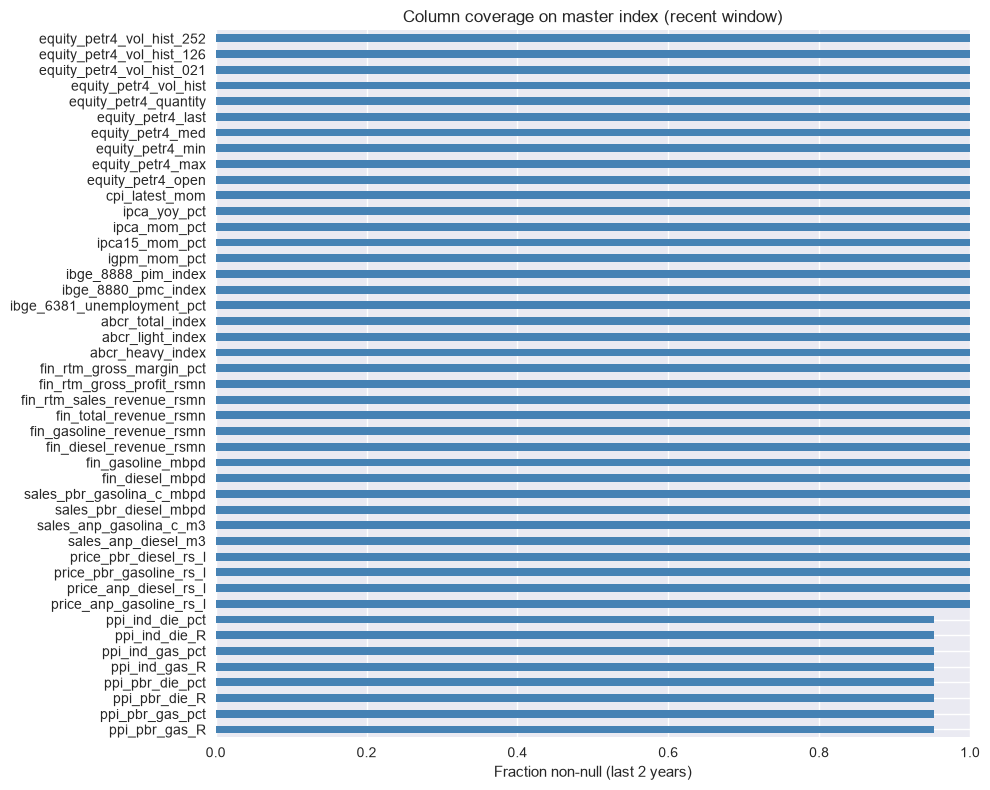

In [10]:
recent = master_df.loc[master_df.index >= (master_df.index.max() - pd.DateOffset(years=2))]
miss_pct = recent.notna().mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
miss_pct.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Fraction non-null (last 2 years)')
ax.set_title('Column coverage on master index (recent window)')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

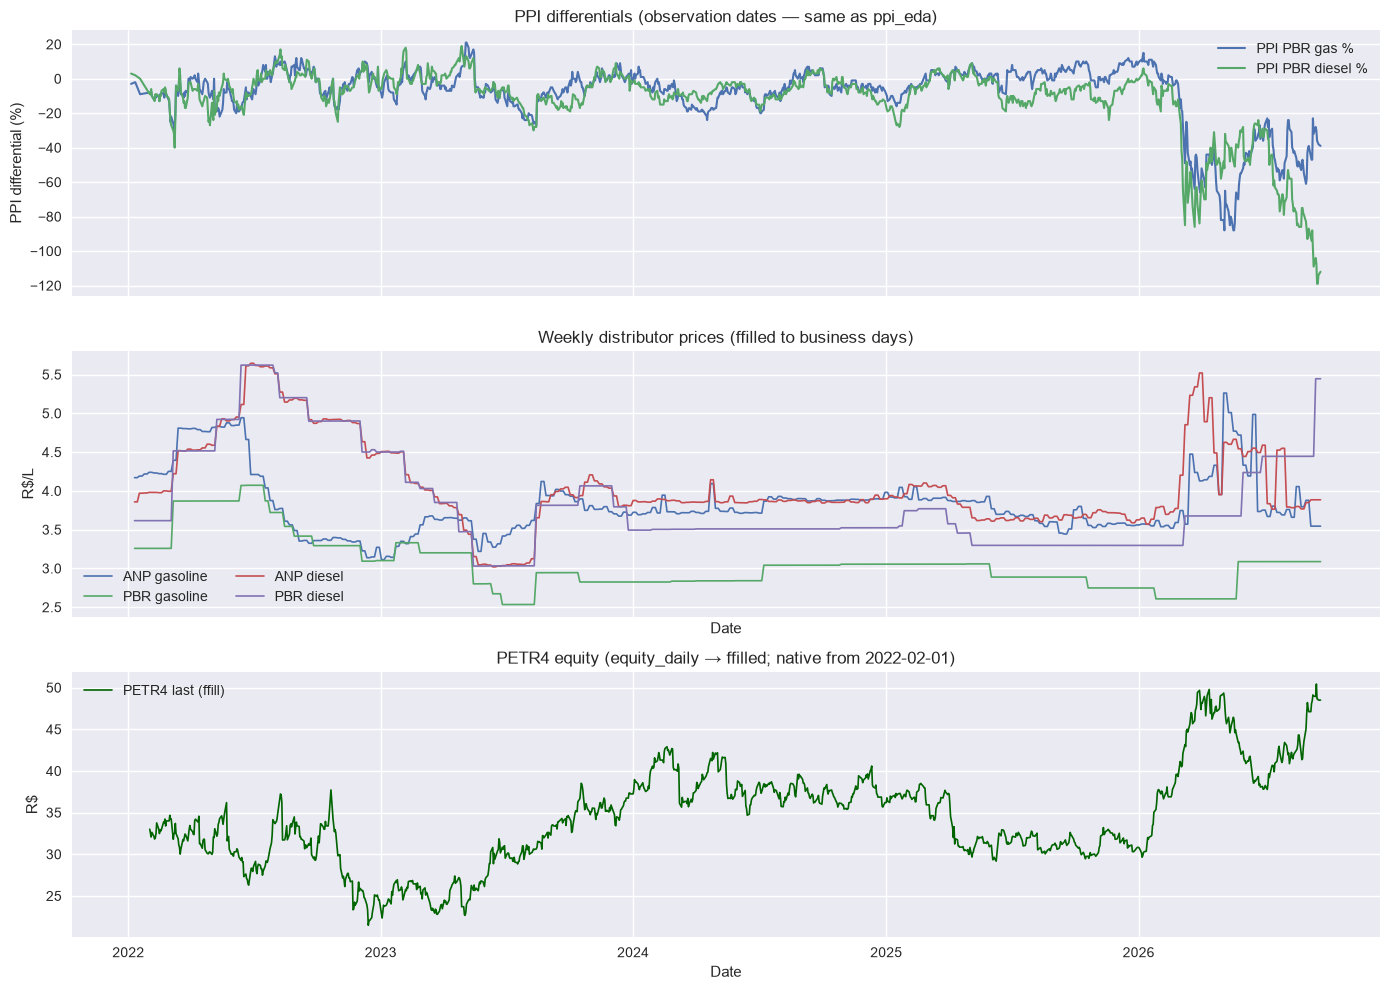

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot PPI on observation dates only — not master_df (bdate_range inserts NaN gaps).
ax = axes[0]
if not ppi_wide.empty:
    if 'ppi_pbr_gas_pct' in ppi_wide.columns:
        gas = ppi_wide['ppi_pbr_gas_pct'].dropna()
        ax.plot(gas.index, gas, label='PPI PBR gas %', linewidth=1.5)
    if 'ppi_pbr_die_pct' in ppi_wide.columns:
        die = ppi_wide['ppi_pbr_die_pct'].dropna()
        ax.plot(die.index, die, label='PPI PBR diesel %', linewidth=1.5)
ax.set_ylabel('PPI differential (%)')
ax.set_title('PPI differentials (observation dates — same as ppi_eda)')
ax.legend()

ax = axes[1]
for col, label in [
    ('price_anp_gasoline_rs_l', 'ANP gasoline'),
    ('price_pbr_gasoline_rs_l', 'PBR gasoline'),
    ('price_anp_diesel_rs_l', 'ANP diesel'),
    ('price_pbr_diesel_rs_l', 'PBR diesel'),
]:
    if col in master_df.columns:
        ax.plot(master_df.index, master_df[col], label=label, linewidth=1.2)
ax.set_ylabel('R$/L')
ax.set_xlabel('Date')
ax.set_title('Weekly distributor prices (ffilled to business days)')
ax.legend(ncol=2)

ax = axes[2]
if 'equity_petr4_last' in master_df.columns:
    ax.plot(master_df.index, master_df['equity_petr4_last'], label='PETR4 last (ffill)', linewidth=1.2, color='darkgreen')
ax.set_ylabel('R$')
ax.set_xlabel('Date')
ax.set_title('PETR4 equity (equity_daily → ffilled; native from 2022-02-01)')
ax.legend()

plt.tight_layout()
plt.show()

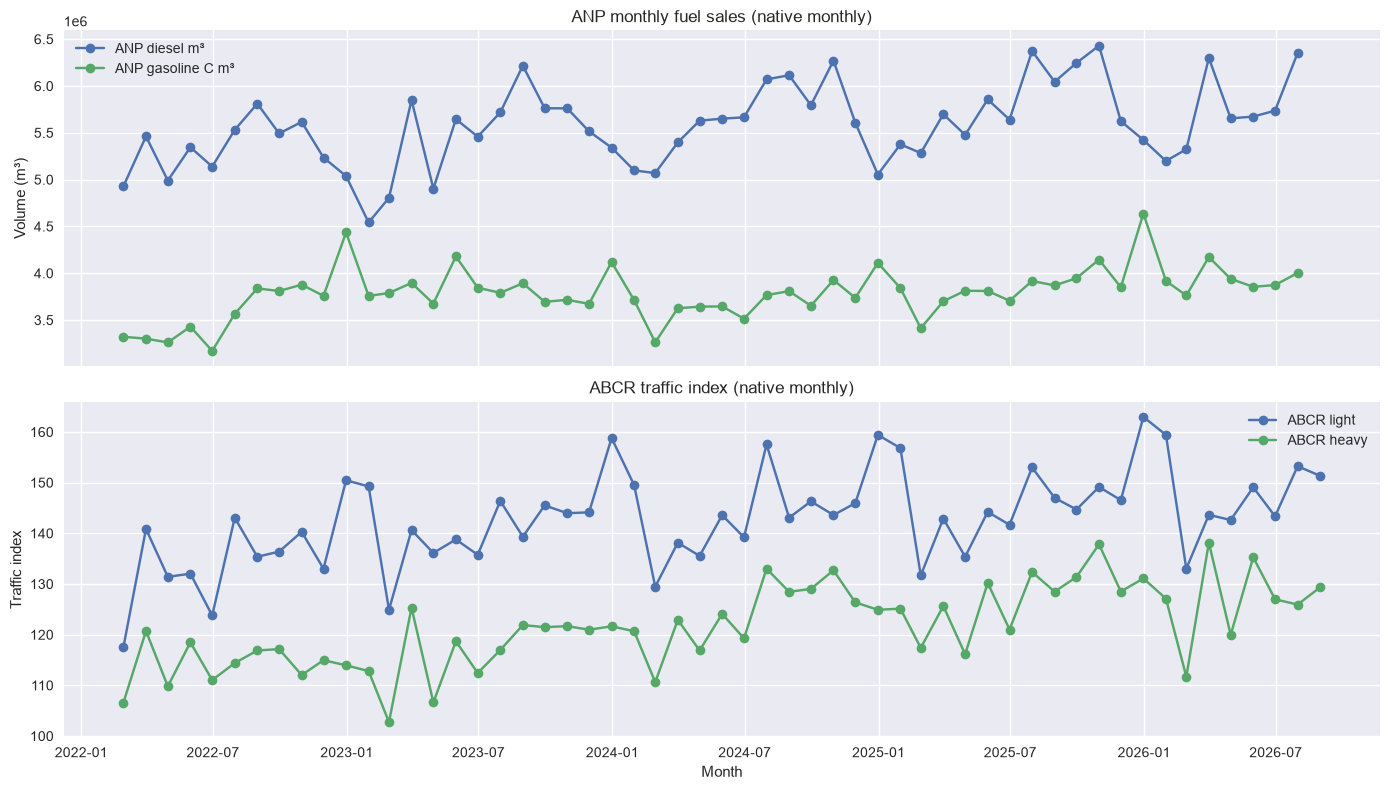

In [12]:
# Plot monthly-native series at month-end for visual comparison (not the ffill view).
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

if not anp_sales_wide.empty:
    month_end = anp_sales_wide.index + pd.offsets.MonthEnd(0)
    ax = axes[0]
    if 'sales_anp_diesel_m3' in anp_sales_wide.columns:
        ax.plot(month_end, anp_sales_wide['sales_anp_diesel_m3'], marker='o', label='ANP diesel m³')
    if 'sales_anp_gasolina_c_m3' in anp_sales_wide.columns:
        ax.plot(month_end, anp_sales_wide['sales_anp_gasolina_c_m3'], marker='o', label='ANP gasoline C m³')
    ax.set_ylabel('Volume (m³)')
    ax.set_title('ANP monthly fuel sales (native monthly)')
    ax.legend()

if not abcr_wide.empty:
    month_end = abcr_wide.index + pd.offsets.MonthEnd(0)
    ax = axes[1]
    for col, label in [
        ('abcr_light_index', 'ABCR light'),
        ('abcr_heavy_index', 'ABCR heavy'),
    ]:
        if col in abcr_wide.columns:
            ax.plot(month_end, abcr_wide[col], marker='o', label=label)
    ax.set_ylabel('Traffic index')
    ax.set_xlabel('Month')
    ax.set_title('ABCR traffic index (native monthly)')
    ax.legend()

plt.tight_layout()
plt.show()

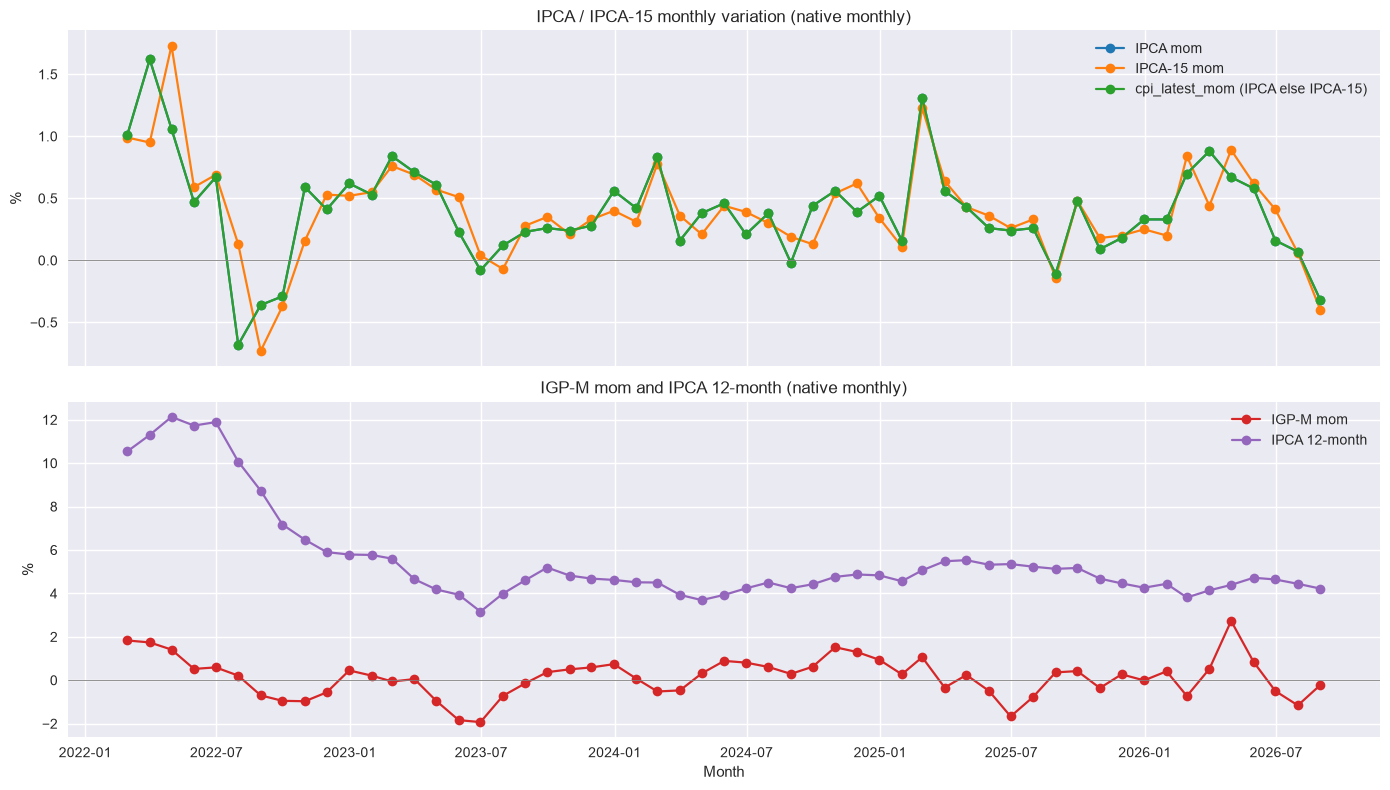

In [13]:
# Native monthly inflation prints (not the ffill view).
if inflation_wide.empty:
    print('inflation_monthly empty — check data/gas_flare.sqlite')
else:
    month_end = inflation_wide.index + pd.offsets.MonthEnd(0)
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax = axes[0]
    for col, label, color in [
        ('ipca_mom_pct', 'IPCA mom', '#1f77b4'),
        ('ipca15_mom_pct', 'IPCA-15 mom', '#ff7f0e'),
        ('cpi_latest_mom', 'cpi_latest_mom (IPCA else IPCA-15)', '#2ca02c'),
    ]:
        if col in inflation_wide.columns:
            ax.plot(month_end, inflation_wide[col], marker='o', linewidth=1.6, color=color, label=label)
    ax.axhline(0, color='grey', linewidth=0.6)
    ax.set_ylabel('%')
    ax.set_title('IPCA / IPCA-15 monthly variation (native monthly)')
    ax.legend()

    ax = axes[1]
    if 'igpm_mom_pct' in inflation_wide.columns:
        ax.plot(month_end, inflation_wide['igpm_mom_pct'], marker='o', linewidth=1.6, color='#d62728', label='IGP-M mom')
    if 'ipca_yoy_pct' in inflation_wide.columns:
        ax.plot(month_end, inflation_wide['ipca_yoy_pct'], marker='o', linewidth=1.6, color='#9467bd', label='IPCA 12-month')
    ax.axhline(0, color='grey', linewidth=0.6)
    ax.set_ylabel('%')
    ax.set_xlabel('Month')
    ax.set_title('IGP-M mom and IPCA 12-month (native monthly)')
    ax.legend()
    plt.tight_layout()
    plt.show()


## Indicadores de atividade IBGE vs. vendas

Proxies mensais SIDRA em `ibge_indicators`:

| Coluna | Série | Ligação esperada com a demanda |
|--------|--------|------------------------|
| `ibge_8888_pim_index` | Produção industrial (PIM-PF) | Frete / diesel |
| `ibge_8880_pmc_index` | Volume do varejo (PMC) | Mobilidade / gasolina |
| `ibge_6381_unemployment_pct` | Desemprego PNAD | Proxy inverso de atividade |

**Nota do IBGE:** a defasagem da fonte é mensal, cerca de 1,5 a 2 meses, na mesma faixa das vendas ANP. Não é nowcast em tempo real. O valor aqui é o sinal de atividade (PIM-PF com diesel, PMC com gasolina) enquanto o volume oficial não sai.

Na sobreposição mensal nativa com as vendas ANP, as séries IBGE mostram as correlações mais fortes desta base, à frente do tráfego ABCR. Os gráficos abaixo usam carimbos mensais nativos, não a vista preenchida do `master_df`.


IBGE freshness (native monthly, as of notebook run):


,series,latest_month,age_days
0,6381 — PNAD unemployment (%),2026-07-01,88
1,8880 — Retail trade volume (PMC),2026-07-01,88
2,8888 — Industrial production (PIM-PF),2026-07-01,88


Readiness (monthly cadence): YELLOW — newest month is 88 days old (green ≤80, yellow ≤110)


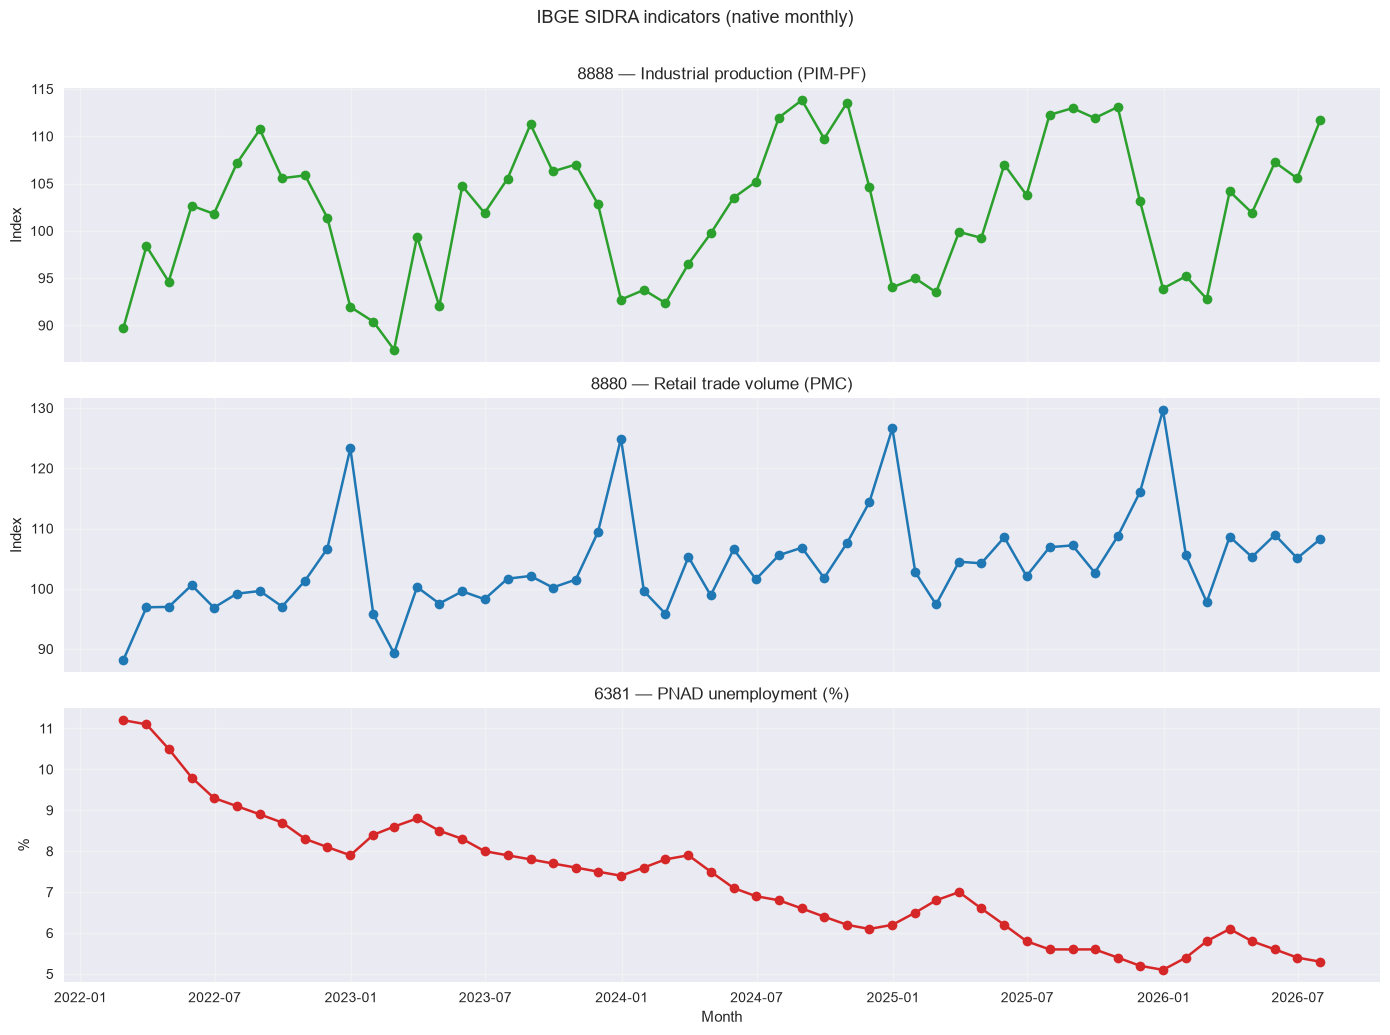

In [14]:
IBGE_LABELS = {
    'ibge_6381_unemployment_pct': '6381 — PNAD unemployment (%)',
    'ibge_8880_pmc_index': '8880 — Retail trade volume (PMC)',
    'ibge_8888_pim_index': '8888 — Industrial production (PIM-PF)',
}

if not ibge_wide.empty:
    today = pd.Timestamp.today().normalize()
    freshness = []
    for col in IBGE_LABELS:
        if col not in ibge_wide.columns:
            continue
        latest = ibge_wide[col].dropna().index.max()
        age_days = (today - latest).days
        freshness.append({'series': IBGE_LABELS[col], 'latest_month': latest.date(), 'age_days': age_days})
    fresh_df = pd.DataFrame(freshness)
    print('IBGE freshness (native monthly, as of notebook run):')
    display(fresh_df)
    max_age = int(fresh_df['age_days'].max())
    if max_age <= 80:
        status = 'GREEN'
    elif max_age <= 110:
        status = 'YELLOW'
    else:
        status = 'RED'
    print(f'Readiness (monthly cadence): {status} — newest month is {max_age} days old (green ≤80, yellow ≤110)')

if ibge_wide.empty:
    print('IBGE table empty — run: python -m src.predictors.pipeline ibge')
else:
    month_end = ibge_wide.index + pd.offsets.MonthEnd(0)
    series = [
        ('ibge_8888_pim_index', '#2ca02c'),
        ('ibge_8880_pmc_index', '#1f77b4'),
        ('ibge_6381_unemployment_pct', '#d62728'),
    ]
    fig, axes = plt.subplots(len(series), 1, figsize=(14, 3.4 * len(series)), sharex=True)
    axes = np.atleast_1d(axes)

    for ax, (col, color) in zip(axes, series):
        if col not in ibge_wide.columns:
            continue
        ax.plot(month_end, ibge_wide[col], marker='o', linewidth=1.8, color=color)
        ax.set_title(IBGE_LABELS.get(col, col))
        ax.set_ylabel('Index' if 'pct' not in col else '%')
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Month')
    fig.suptitle('IBGE SIDRA indicators (native monthly)', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()

sales_series,diesel,gasolina_c
proxy,,
abcr_heavy_index,0.741,0.459
abcr_light_index,0.300,0.649
abcr_total_index,0.382,0.648
ibge_6381_unemployment_pct,-0.491,-0.556
ibge_8880_pmc_index,0.197,0.694
ibge_8888_pim_index,0.883,0.136


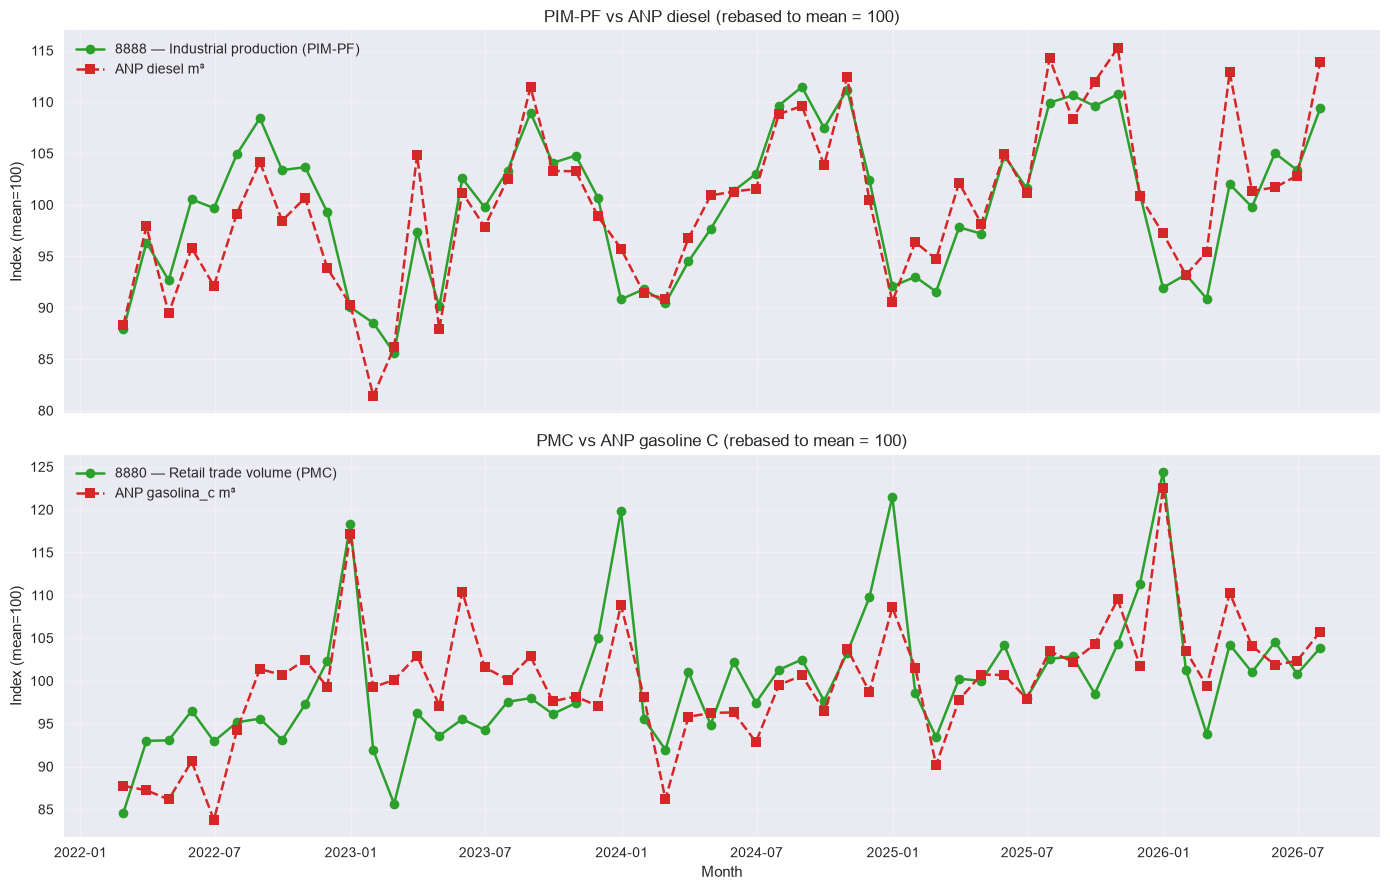

In [15]:
def rebase(s):
    s = s.dropna()
    return s / s.mean() * 100.0 if not s.empty and s.mean() else s


sales_cols = ['sales_anp_diesel_m3', 'sales_anp_gasolina_c_m3']
ibge_cols = [c for c in ibge_wide.columns if c.startswith('ibge_')]
abcr_cols = [c for c in abcr_wide.columns if c.startswith('abcr_')]

monthly_native = anp_sales_wide.join(ibge_wide, how='inner')
if not abcr_wide.empty:
    monthly_native = monthly_native.join(abcr_wide, how='inner')

if monthly_native.empty:
    print('Need overlapping ANP sales and IBGE months for correlation.')
else:
    proxy_cols = ibge_cols + abcr_cols
    corr_rows = []
    for sales_col in sales_cols:
        if sales_col not in monthly_native.columns:
            continue
        for proxy_col in proxy_cols:
            pair = monthly_native[[proxy_col, sales_col]].dropna()
            if len(pair) < 6:
                continue
            corr_rows.append({
                'sales_series': sales_col.replace('sales_anp_', '').replace('_m3', ''),
                'proxy': proxy_col,
                'family': 'IBGE' if proxy_col.startswith('ibge_') else 'ABCR',
                'r': pair[proxy_col].corr(pair[sales_col]),
                'n_months': len(pair),
            })

    corr_df = pd.DataFrame(corr_rows).sort_values(['sales_series', 'r'], ascending=[True, False])
    display(corr_df.pivot(index='proxy', columns='sales_series', values='r').round(3))

    overlay_pairs = [
        ('ibge_8888_pim_index', 'sales_anp_diesel_m3', 'PIM-PF vs ANP diesel'),
        ('ibge_8880_pmc_index', 'sales_anp_gasolina_c_m3', 'PMC vs ANP gasoline C'),
    ]

    fig, axes = plt.subplots(len(overlay_pairs), 1, figsize=(14, 4.5 * len(overlay_pairs)), sharex=True)
    axes = np.atleast_1d(axes)
    month_end = monthly_native.index + pd.offsets.MonthEnd(0)

    for ax, (proxy_col, sales_col, title) in zip(axes, overlay_pairs):
        if proxy_col in monthly_native.columns:
            ax.plot(
                month_end, rebase(monthly_native[proxy_col]),
                color='#2ca02c', linewidth=1.8, marker='o', label=IBGE_LABELS.get(proxy_col, proxy_col),
            )
        if sales_col in monthly_native.columns:
            ax.plot(
                month_end, rebase(monthly_native[sales_col]),
                color='#d62728', linewidth=1.8, linestyle='--', marker='s',
                label=sales_col.replace('sales_anp_', 'ANP ').replace('_m3', ' m³'),
            )
        ax.set_title(f'{title} (rebased to mean = 100)')
        ax.set_ylabel('Index (mean=100)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')

    axes[-1].set_xlabel('Month')
    plt.tight_layout()
    plt.show()

PBR diesel Mbpd reconciliation: 18 quarters, max |diff| = 0.0 Mbpd


,sales_pbr_diesel_mbpd,fin_diesel_mbpd,diff_mbpd
quarter_end,,,
2025-03-31,734.0,734.0,0.0
2025-06-30,721.0,721.0,0.0
2025-09-30,809.0,809.0,0.0
2025-12-31,787.0,787.0,0.0
2026-03-31,738.0,738.0,0.0
2026-06-30,742.0,742.0,0.0


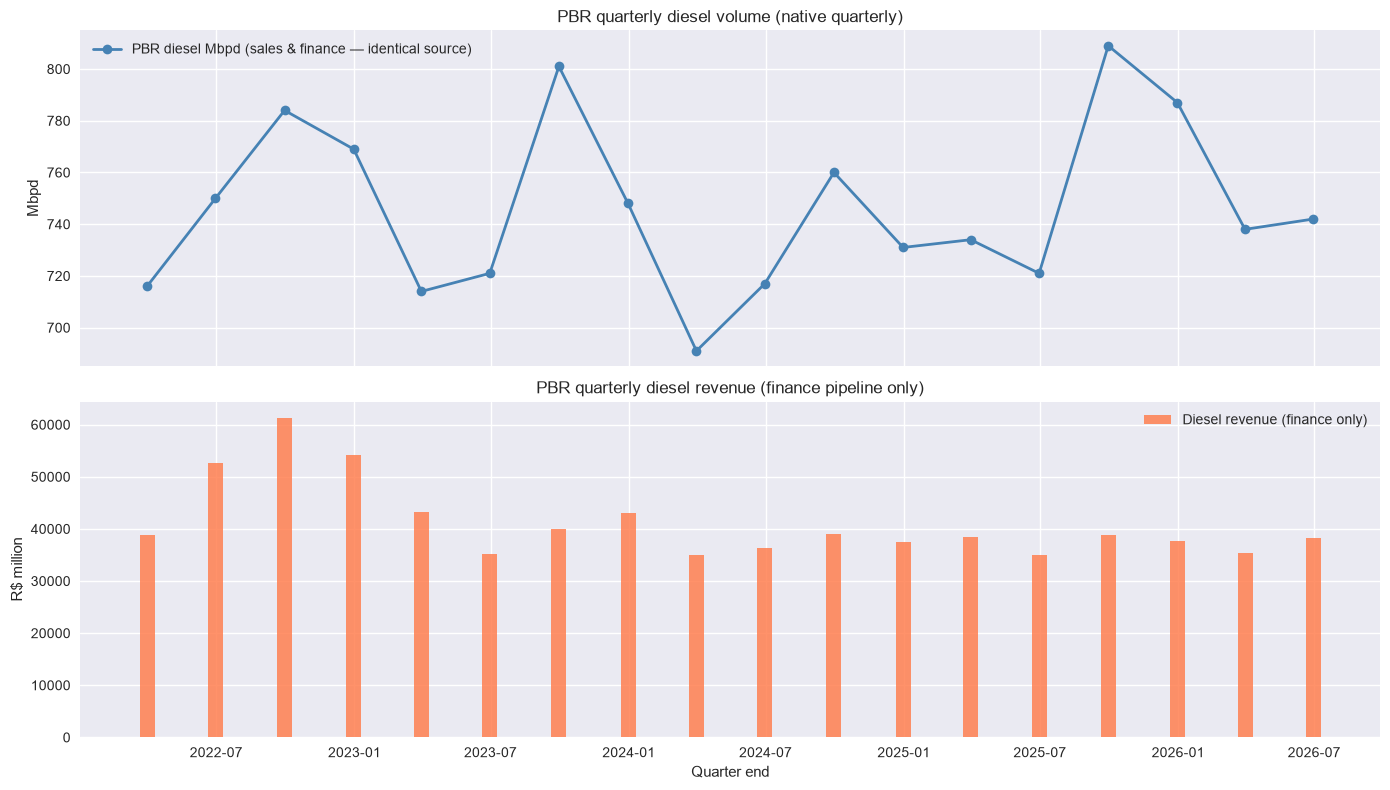

In [16]:
# Sales and finance diesel Mbpd are the same Exhibit I metric — overlaying them is misleading.
# Reconcile first, then split: volume (one line) vs finance-only revenue.
recon = pd.DataFrame()
if (
    not pbr_sales_wide.empty
    and not finance_wide.empty
    and 'sales_pbr_diesel_mbpd' in pbr_sales_wide.columns
    and 'fin_diesel_mbpd' in finance_wide.columns
):
    recon = pbr_sales_wide[['sales_pbr_diesel_mbpd']].join(
        finance_wide[['fin_diesel_mbpd']], how='outer',
    )
    recon['diff_mbpd'] = recon['sales_pbr_diesel_mbpd'] - recon['fin_diesel_mbpd']
    max_abs_diff = recon['diff_mbpd'].abs().max()
    print(
        f'PBR diesel Mbpd reconciliation: {len(recon)} quarters, '
        f'max |diff| = {max_abs_diff:.1f} Mbpd'
    )
    display(recon.tail(6))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
if not pbr_sales_wide.empty and 'sales_pbr_diesel_mbpd' in pbr_sales_wide.columns:
    ax.plot(
        pbr_sales_wide.index, pbr_sales_wide['sales_pbr_diesel_mbpd'],
        marker='o', color='steelblue', linewidth=2,
        label='PBR diesel Mbpd (sales & finance — identical source)',
    )
ax.set_ylabel('Mbpd')
ax.set_title('PBR quarterly diesel volume (native quarterly)')
ax.legend()

ax = axes[1]
if not finance_wide.empty and 'fin_diesel_revenue_rsmn' in finance_wide.columns:
    ax.bar(
        finance_wide.index, finance_wide['fin_diesel_revenue_rsmn'],
        width=20, color='coral', alpha=0.85, label='Diesel revenue (finance only)',
    )
ax.set_ylabel('R$ million')
ax.set_xlabel('Quarter end')
ax.set_title('PBR quarterly diesel revenue (finance pipeline only)')
ax.legend()

plt.tight_layout()
plt.show()

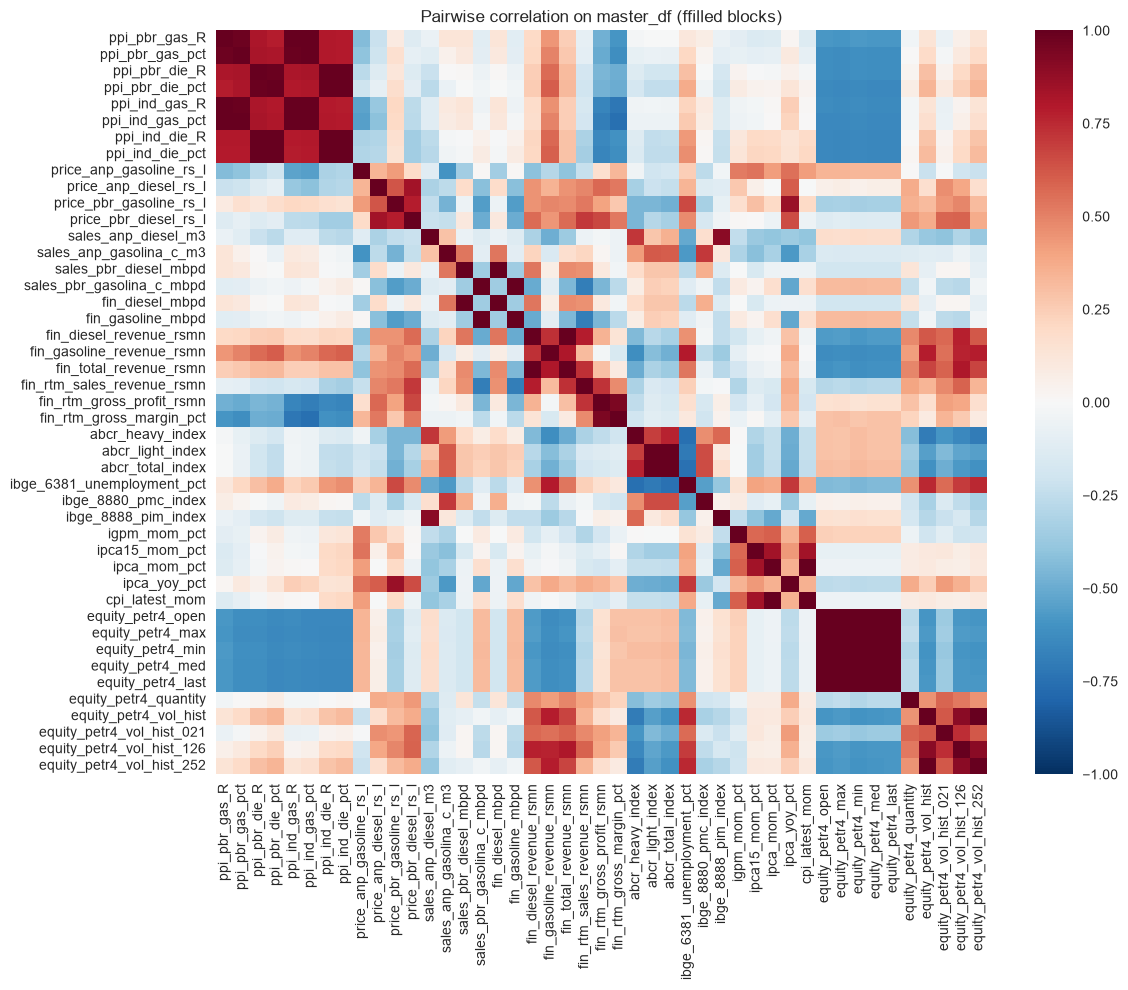

In [17]:
corr_cols = [
    c for c in master_df.columns
    if master_df[c].notna().sum() > 30
]
corr = master_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Pairwise correlation on master_df (ffilled blocks)')
plt.tight_layout()
plt.show()

In [18]:
master_df.tail(10)

,ppi_pbr_gas_R,ppi_pbr_gas_pct,ppi_pbr_die_R,ppi_pbr_die_pct,ppi_ind_gas_R,ppi_ind_gas_pct,ppi_ind_die_R,ppi_ind_die_pct,price_anp_gasoline_rs_l,price_anp_diesel_rs_l,...,equity_petr4_open,equity_petr4_max,equity_petr4_min,equity_petr4_med,equity_petr4_last,equity_petr4_quantity,equity_petr4_vol_hist,equity_petr4_vol_hist_021,equity_petr4_vol_hist_126,equity_petr4_vol_hist_252
date,,,,,,,,,,,,,,,,,,,,,
2026-09-08,-1.19,-47.0,-3.08,-94.0,-1.06,-41.0,-2.77,-82.0,3.5446,3.88462,...,48.10,48.50,47.53,48.06,48.09,34388500.0,0.268548,0.361911,0.304990,0.268548
2026-09-09,-1.20,-47.0,-2.87,-88.0,-1.07,-41.0,-2.56,-77.0,3.5446,3.88462,...,48.74,48.95,48.19,48.51,48.42,40391600.0,0.268587,0.338424,0.304964,0.268587
2026-09-10,-0.70,-23.0,-3.20,-98.0,-0.57,-19.0,-2.86,-85.0,3.5446,3.88462,...,48.91,49.60,48.54,49.11,49.12,43955800.0,0.268332,0.327338,0.299532,0.268332
2026-09-11,-0.97,-32.0,-3.55,-109.0,-0.83,-28.0,-3.21,-95.0,3.5446,3.88462,...,48.50,49.12,48.09,48.67,49.00,27608600.0,0.268363,0.321070,0.299526,0.268363
2026-09-14,-0.83,-28.0,-3.39,-104.0,-0.70,-23.0,-3.05,-91.0,3.5446,3.88462,...,49.51,49.73,48.61,49.19,48.92,32098300.0,0.268323,0.319664,0.299320,0.268323
2026-09-15,-0.90,-30.0,-3.49,-107.0,-0.77,-26.0,-3.15,-94.0,3.5446,3.88462,...,49.06,50.70,49.03,50.21,50.43,46559600.0,0.269396,0.329031,0.301060,0.269396
2026-09-16,-1.09,-36.0,-3.89,-119.0,-0.96,-32.0,-3.55,-105.0,3.5446,3.88462,...,49.94,49.98,48.62,49.00,48.65,52457100.0,0.271908,0.361084,0.304454,0.271908
2026-09-17,-1.12,-37.0,-3.88,-119.0,-0.96,-32.0,-3.40,-102.0,3.5446,3.88462,...,48.03,49.20,47.96,48.55,48.61,32429800.0,0.271785,0.361910,0.303911,0.271785
2026-09-18,-1.15,-38.0,-3.72,-114.0,-0.99,-33.0,-3.24,-97.0,3.5446,3.88462,...,48.40,48.83,48.25,48.50,48.50,52664700.0,0.271732,0.362947,0.303848,0.271732


## Margem bruta do segmento RT&M

A Petrobras **não** publica margem bruta de diesel e gasolina por produto. O processo de finanças grava o segmento **Refining, Transportation & Marketing (RT&M)** da nota 8 do ITR.


,fin_rtm_gross_profit_rsmn,fin_rtm_gross_margin_pct
quarter_end,,
2022-03-31,16311.0,12.696
2022-06-30,25532.0,16.218
2022-09-30,14428.0,9.367
2022-12-31,17493.0,12.084
2023-03-31,15449.0,11.971
2023-06-30,8619.0,8.261
2023-09-30,11235.0,9.706
2023-12-31,10777.0,8.607
2024-03-31,10934.0,9.949


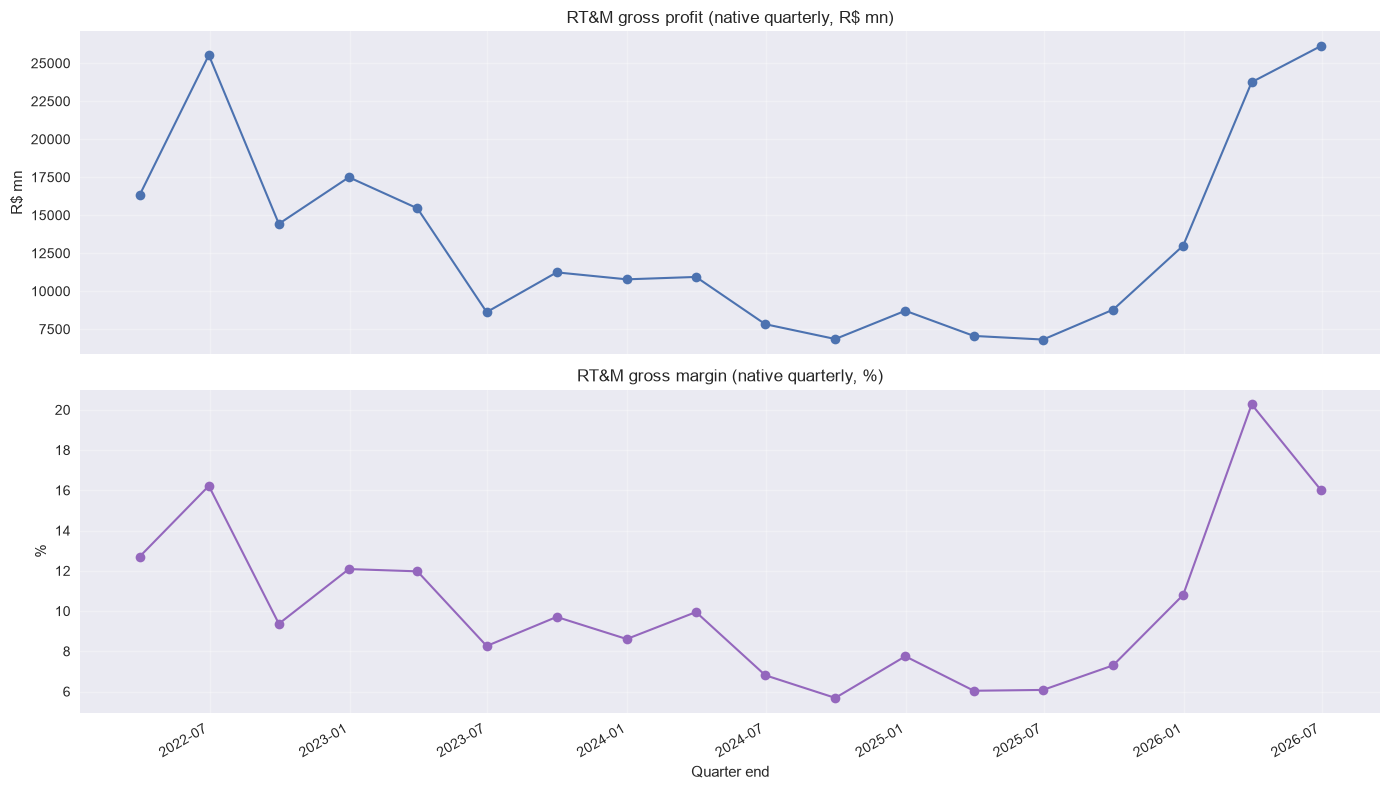

In [19]:
rtm_cols = ['fin_rtm_gross_profit_rsmn', 'fin_rtm_gross_margin_pct']
rtm_native = finance_wide[rtm_cols].dropna(how='all')
display(rtm_native.round(3))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(rtm_native.index, rtm_native['fin_rtm_gross_profit_rsmn'], marker='o', linewidth=1.5)
axes[0].set_title('RT&M gross profit (native quarterly, R$ mn)')
axes[0].set_ylabel('R$ mn')
axes[0].grid(True, alpha=0.3)

axes[1].plot(rtm_native.index, rtm_native['fin_rtm_gross_margin_pct'], marker='o', linewidth=1.5, color='tab:purple')
axes[1].set_title('RT&M gross margin (native quarterly, %)')
axes[1].set_xlabel('Quarter end')
axes[1].set_ylabel('%')
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()